Today we are going to learn programming using a computer "language" called R. R is used every day to do real science!

We're going to write our code today in this coding notebook. This allows us to write R code on the internet, sort of like Google Docs.

Computer code is very specific instructions for what the computer should do. In this notebook, each bit of code or instructions is inside of a "cell." You can make the computer follow the instructions in a cell by pressing the "Play" button in the top-left corner. We call this "running" a cell.

Getting instructions out of order can be very confusing for people, and it's the same for computers. If you run cells out of order the computer might get confused and not work right.


# Packages and Libraries
A lot of times, someone has already written a function (you can think of this like instructions for the computer) for what we need, which can be found in an **R library or package**. These are a collection of pre-written functions that can help us perform tasks like data visualization or analysis so that we don't have to write all of our functions from scratch!

Before we use a library, we need to install it. Let's start by installing a package called ggplot2, which is a useful tool for making plots:

In [ ]:
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Now that we've installed it, we load it. We need to do this every time we start a new R session:

In [ ]:
library(ggplot2)



# Phylogenetics: DNA Decodes the Family Tree of Life
## Loading Necessary Helper files

<font color = "red"> **‼️You have to run cells in this section or else the rest of the activity won't work‼️**

This imports a bunch of functions that we've written to help you. Note: installing and loading the libraries might take a second!

In [ ]:
# Install and load necessary packages
install.packages('ape')
install.packages('ggplot2')
install.packages('tidyr')
library(ape)
library(ggplot2)
library(tidyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘timeR’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


ERROR: Error in library(timeR): there is no package called ‘timeR’


In [ ]:
# get needed functions we have prepared for you
# system('git clone https://github.com/UCCOMBO/Phylogenetics')
# Read the sequence table
sequence_table <- read.delim('https://raw.githubusercontent.com/UCCOMBO/Phylogenetics/refs/heads/main/sample_sequence_table.tsv', sep = "\t", header = TRUE, stringsAsFactors = FALSE)
# load a function to format data
source("https://raw.githubusercontent.com/UCCOMBO/Phylogenetics/refs/heads/main/format_fasta.R")
source("https://raw.githubusercontent.com/UCCOMBO/Phylogenetics/refs/heads/main/create_spp_data.R")

## Scientific Data Exploration

Let's pretend that you are a scientist from another planet. You want to figure out how similar different animals are to each other in a dataset you received from your human collaborators. You are familiar with your human collaborator, so you want to compare the other animals to them as a reference.

Your collaborator has sent you some basic data to analyze. They have sent you some information on traits/features the animals have as well as their DNA sequence.

### Exploring animal traits

Let's begin by looking at some of the traits/features the animals have and seeing what we may be able to learn about them.

In [ ]:
species_features <- data.frame("Mouse" = c(1, 1, 1, 0, 1), "Dolphin" = c(1, 1, 1, 0, 0),
                               "Worm" = c(0, 1, 0, 0, 0), "Human" = c(1, 1, 1, 1, 1),
                               "Clownfish" = c(1, 1, 0, 0, 0))
row.names(species_features) <- c("Bones", "Skin", "Lungs", "2 Legs", "Fur or Hair")

species_features

,Mouse,Dolphin,Worm,Human,Clownfish
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Bones,1,1,0,1,1
Skin,1,1,1,1,1
Lungs,1,1,0,1,0
2 Legs,0,0,0,1,0
Fur or Hair,1,0,0,1,0


We're given a table of each species as well as information about some of their traits. The boxes with 1s indicate that the species has the trait, and the 0s indicate that the species does not have the trait.

What if we were asked to find the total number of species with each feature? We could visualize this on a bar plot.

We will use a package called `ggplot2` to make plots in this section. The code might look a little different than other code we've showed you - don't worry about it! R software developers use a wide range of grammar when creating these packages.

**Challenge**

See if you can pick up on how `ggplot` specifies the following:
- X and Y variables
- color of the plot
- type of plot

Can you make your own modifications to these plots? Ask your volunteer for more help!

Features,Count
<chr>,<dbl>
Bones,4
Skin,5
Lungs,3
2 Legs,1
Fur or Hair,2


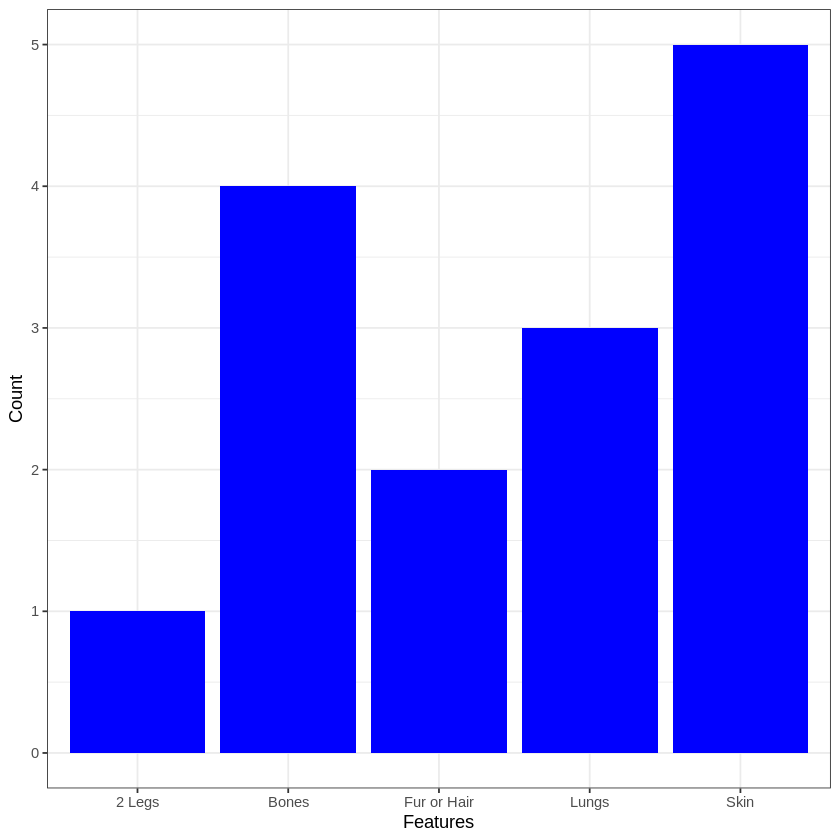

In [ ]:
# Sum up total number of species with each feature and save in simpler table
sum_species <- data.frame("Features" = row.names(species_features),
                          "Count" = rowSums(species_features))
row.names(sum_species) <- NULL
sum_species

# Create bar plot
ggplot(sum_species, aes(x=Features, y=Count )) +
  geom_bar(stat = "identity", fill="blue") +
  theme_bw()

Let's say we were also given information about the heights of various humans in our dataset. An easy way to visualize the distribution of these heights and figure out things like median and range might be a boxplot.

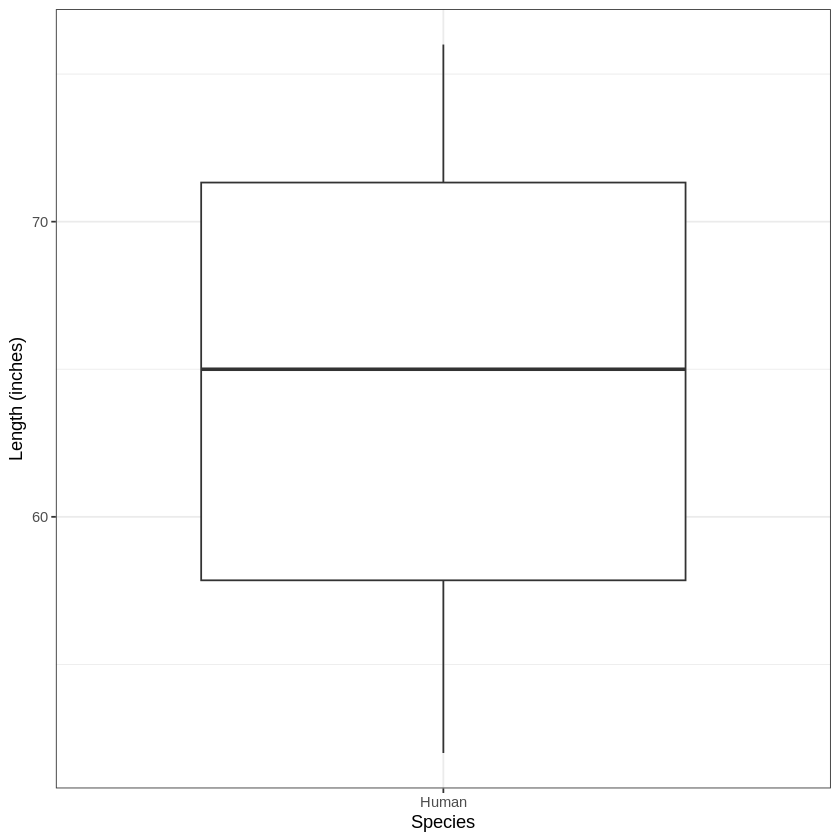

In [ ]:
# Zoom in on just humans
human_only <- data.frame("Species" = rep("Human", 10),
                         "Length" = c(52, 64, 69, 75.3, 76, 57, 72.1, 66, 56.4, 60.4))

ggplot(human_only, aes(x=Species, y=Length)) +
  geom_boxplot() + ylab("Length (inches)") +
  theme_bw()

#

##Exploring DNA Sequences

Now let's try making a tree based off of genetic differences between our animals!

Counting up differences and making trees from DNA gets harder the more DNA you are comparing. The more DNA you compare, the more confident you can be that your tree is accurate. Therefore, we use computers to speed up the comparison and allow us to use large datasets.

Let's look at some of the data we are going to use to make trees with R.

In [ ]:
head(sequence_table)

,human,mouse,dolphin,clownfish,worm
,<chr>,<chr>,<chr>,<chr>,<chr>
1,TAATCGACTCACGGGC,TAATCGACTCCCGGGC,TATTCGACTCACGGGC,TAAGCGACTCACGGGC,AGATTCACTAGCTGGC
2,TCCTATCCCGTTCCTC,TCCTATCCCGTGACTC,TCCTATCCCGTTCCTC,TCAAAGCCCGTTCATC,TCGCAGAGAGTTTGTT
3,AGGGTGGAGACCTTTC,AGGGTGCAGACCTTTC,AGGGTGGAGACCTTTC,CAGGTGGAGACCTTTC,TAAACATAGTCAATCC
4,TACGTTAAACGGTTAT,TACGTTAAACGTTTAT,TACGTTTAACGAGCAC,AACGTAGCTTGGTTTG,CCTAAGGAATCGATTT
5,CCGTACGCTTCACCAT,CCGTGCCCTTCACCAT,CGGTACGCTTCGCCAT,CACTACGCCTGAATAT,CCGAGCGCCCCAGAGC


This table shows the DNA sequences for our different animal species which we will use for our trees. Each of the columns is an animal species, and each row is a gene. This is a lot to look at!

We will compare the number of differences between the sequences. Here we will let the computer count the differences between all combinations - human v. mouse, human v. worm, mouse v. worm, etc.

Let's try looking at the differences between species for gene 1. The computer can do this comparison much faster than humans do. This next code chunk includes a timer so you can see how fast it works!

In [ ]:
# Make dataframe to store all species and their genomes
species_genomes_df <- data.frame(Species = character(), Genome = character(), stringsAsFactors = FALSE)

# Loop over species (columns) and concatenate sequences using rbind()
for (species in colnames(sequence_table)) {
  # Combine all sequences for the current species
  genome_sequence <- paste(sequence_table[[species]], collapse = "")

  # Append to dataframe using rbind
  species_genomes_df <- rbind(species_genomes_df, data.frame(Species = species, Genome = genome_sequence))
}

start_time <- proc.time()

genome_mat = genome_fasta_format(species_genomes_df)
genome_dist_mat = dist.gene(genome_mat)
genome_dist_mat

elapsed <- proc.time() - start_time
cat("Time elapsed:", elapsed["elapsed"], "seconds\n")

          human mouse dolphin clownfish
mouse         7                        
dolphin       8    14                  
clownfish    21    28      26          
worm         46    48      52        47

Time elapsed: 0.01 seconds


Faster than if we did this on paper, right? This code gives us a table with the number of differences between each pair of animals.

Now we will use this comparison to draw a tree, just like you did on your worksheet.

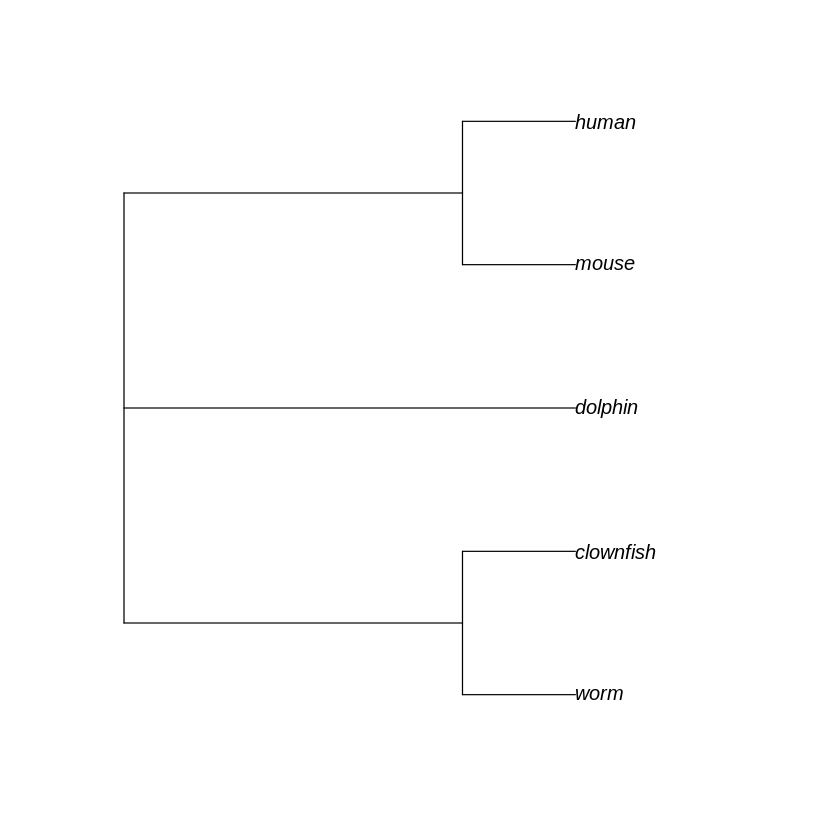

In [ ]:
# build the phylogenetic tree
nj_tree <- bionj(genome_dist_mat)

# plot tree
plot.phylo(nj_tree, use.edge.length=F)

Does this tree look the way you expect?

###Some questions to discuss with your neighbors:

Based on the tree, which organisms are most closely related? Does this make sense to you based on what you know about these organisms?
How do the animals on the different parts of the tree share traits?


Sometimes, scientists are faced with this problem in real life - traits and small differences between organisms can be tricky to measure at a large scale. Sometimes, there is variation in these traits depending on who took the measurement or what instrument they used. Using DNA sequencing and looking at the simple differences between organisms has changed the way scientists see the world!